In [1]:
# ==========================================
# STEP 1: IMPORTS
# ==========================================

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

from PIL import Image
from tqdm import tqdm

print("=" * 60)
print("[SUCCESS] All libraries imported successfully.")
print("=" * 60)

[SUCCESS] All libraries imported successfully.


In [2]:
# ==========================================
# STEP 2: RANDOM SEEDS + GPU SETUP
# ==========================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("=" * 60)
print("[INFO] Device :", device)

if torch.cuda.is_available():
    print("[INFO] GPU Name :", torch.cuda.get_device_name(0))

print("=" * 60)
print("[SUCCESS] Seed and device setup completed.")
print("=" * 60)

[INFO] Device : cuda
[INFO] GPU Name : NVIDIA RTX A2000 Laptop GPU
[SUCCESS] Seed and device setup completed.


In [3]:
# ==========================================
# STEP 3: LOAD METADATA CSV
# ==========================================

print("=" * 60)
print("[INFO] Loading metadata...")
print("=" * 60)

df = pd.read_csv(
    "../data/raw/HAM10000_metadata.csv"
)

print("[INFO] Dataset Shape :", df.shape)

print("=" * 60)
print("[SUCCESS] Metadata loaded successfully.")
print("=" * 60)

df.head()

[INFO] Loading metadata...
[INFO] Dataset Shape : (10015, 7)
[SUCCESS] Metadata loaded successfully.


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [4]:
import os

print(os.getcwd())

d:\6thsemesterstudy\DL theory\DermAI-Skin-Cancer-Classification\notebooks


In [5]:
# ==========================================
# STEP 4: CREATE IMAGE PATHS + ENCODE LABELS
# ==========================================

print("=" * 60)
print("[INFO] Creating image paths and encoding labels...")
print("=" * 60)

# Label mapping
label_mapping = {
    "akiec": 0,
    "bcc": 1,
    "bkl": 2,
    "df": 3,
    "mel": 4,
    "nv": 5,
    "vasc": 6
}

# Encode labels
df["label"] = df["dx"].map(label_mapping)

# Create image path dictionary
image_dir_1 = "../data/raw/HAM10000_images_part_1"
image_dir_2 = "../data/raw/HAM10000_images_part_2"

image_paths = {}

for image_id in df["image_id"]:

    path_1 = os.path.join(image_dir_1, image_id + ".jpg")
    path_2 = os.path.join(image_dir_2, image_id + ".jpg")

    if os.path.exists(path_1):
        image_paths[image_id] = path_1
    else:
        image_paths[image_id] = path_2

# Add image paths to dataframe
df["image_path"] = df["image_id"].map(image_paths)

print("[INFO] Dataset Shape :", df.shape)

print("=" * 60)
print("[SUCCESS] Image paths and labels created.")
print("=" * 60)

df.head()

[INFO] Creating image paths and encoding labels...
[INFO] Dataset Shape : (10015, 9)
[SUCCESS] Image paths and labels created.


,lesion_id,image_id,dx,dx_type,age,sex,localization,label,image_path
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,2,../data/raw/HAM10000_images_part_1\ISIC_002741...
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,2,../data/raw/HAM10000_images_part_1\ISIC_002503...
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,2,../data/raw/HAM10000_images_part_1\ISIC_002676...
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,2,../data/raw/HAM10000_images_part_1\ISIC_002566...
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,2,../data/raw/HAM10000_images_part_2\ISIC_003163...


In [6]:
# ==========================================
# STEP 5: TRAIN / VALIDATION / TEST SPLIT
# ==========================================

print("=" * 60)
print("[INFO] Splitting dataset...")
print("=" * 60)

# Train (70%) and Temp (30%)
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=SEED
)

# Validation (15%) and Test (15%)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED
)

print("[INFO] Training Images   :", len(train_df))
print("[INFO] Validation Images :", len(val_df))
print("[INFO] Test Images       :", len(test_df))

print("=" * 60)
print("[SUCCESS] Dataset split completed.")
print("=" * 60)

[INFO] Splitting dataset...
[INFO] Training Images   : 7010
[INFO] Validation Images : 1502
[INFO] Test Images       : 1503
[SUCCESS] Dataset split completed.


In [7]:
# ==========================================
# STEP 6: IMAGE TRANSFORMATIONS
# ==========================================

print("=" * 60)
print("[INFO] Creating image transformations...")
print("=" * 60)

# Training transformations
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),

    # ImageNet normalization (required for pretrained ResNet50)
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Validation/Test transformations
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = val_transform

print("=" * 60)
print("[SUCCESS] Transformations created.")
print("=" * 60)

[INFO] Creating image transformations...
[SUCCESS] Transformations created.


In [8]:
# ==========================================
# STEP 7: DATASET CLASS
# ==========================================

class HAM10000Dataset(Dataset):

    def __init__(self, dataframe, transform=None):

        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):

        return len(self.dataframe)

    def __getitem__(self, idx):

        # Image path
        image_path = self.dataframe.loc[idx, "image_path"]

        # Label
        label = self.dataframe.loc[idx, "label"]

        # Open image
        image = Image.open(image_path).convert("RGB")

        # Apply transforms
        if self.transform:
            image = self.transform(image)

        return image, label


print("=" * 60)
print("[SUCCESS] Dataset class created successfully.")
print("=" * 60)

[SUCCESS] Dataset class created successfully.


In [9]:
# ==========================================
# STEP 8: CREATE DATASETS
# ==========================================

print("=" * 60)
print("[INFO] Creating datasets...")
print("=" * 60)

train_dataset = HAM10000Dataset(
    dataframe=train_df,
    transform=train_transform
)

val_dataset = HAM10000Dataset(
    dataframe=val_df,
    transform=val_transform
)

test_dataset = HAM10000Dataset(
    dataframe=test_df,
    transform=test_transform
)

print("[INFO] Train Dataset Size :", len(train_dataset))
print("[INFO] Validation Dataset Size :", len(val_dataset))
print("[INFO] Test Dataset Size :", len(test_dataset))

print("=" * 60)
print("[SUCCESS] Datasets created successfully.")
print("=" * 60)

[INFO] Creating datasets...
[INFO] Train Dataset Size : 7010
[INFO] Validation Dataset Size : 1502
[INFO] Test Dataset Size : 1503
[SUCCESS] Datasets created successfully.


In [10]:
# ==========================================
# STEP 9: CREATE DATALOADERS
# ==========================================

print("=" * 60)
print("[INFO] Creating DataLoaders...")
print("=" * 60)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print("[INFO] Train Batches :", len(train_loader))
print("[INFO] Validation Batches :", len(val_loader))
print("[INFO] Test Batches :", len(test_loader))

print("=" * 60)
print("[SUCCESS] DataLoaders created successfully.")
print("=" * 60)

[INFO] Creating DataLoaders...
[INFO] Train Batches : 220
[INFO] Validation Batches : 47
[INFO] Test Batches : 47
[SUCCESS] DataLoaders created successfully.


In [11]:
# ==========================================
# STEP 10: TEST DATALOADER
# ==========================================

print("=" * 60)
print("[INFO] Testing DataLoader...")
print("=" * 60)

images, labels = next(iter(train_loader))

print("[INFO] Images Shape :", images.shape)
print("[INFO] Labels Shape :", labels.shape)

print("=" * 60)
print("[SUCCESS] DataLoader test completed.")
print("=" * 60)

[INFO] Testing DataLoader...
[INFO] Images Shape : torch.Size([32, 3, 224, 224])
[INFO] Labels Shape : torch.Size([32])
[SUCCESS] DataLoader test completed.


In [12]:
# ==========================================
# STEP 11: LOAD PRETRAINED RESNET50
# ==========================================

from torchvision.models import resnet50, ResNet50_Weights

print("=" * 60)
print("[INFO] Loading ResNet50...")
print("=" * 60)

weights = ResNet50_Weights.DEFAULT

model = resnet50(weights=weights)

print(model)

print("=" * 60)
print("[SUCCESS] ResNet50 loaded successfully.")
print("=" * 60)

[INFO] Loading ResNet50...
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\Muhammad Iqbal/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:36<00:00, 2.78MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [13]:
# ==========================================
# STEP 12: FREEZE LAYERS + MODIFY FC
# ==========================================

print("=" * 60)
print("[INFO] Freezing layers...")
print("=" * 60)

# Freeze everything
for param in model.parameters():
    param.requires_grad = False

# Unfreeze layer4
for param in model.layer4.parameters():
    param.requires_grad = True

# Replace FC layer
model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(
        in_features=model.fc.in_features,
        out_features=7
    )
)

# Make FC trainable
for param in model.fc.parameters():
    param.requires_grad = True

# Move model to GPU
model = model.to(device)

print(model.fc)

print("=" * 60)
print("[SUCCESS] Layer freezing and FC replacement completed.")
print("=" * 60)

[INFO] Freezing layers...
Sequential(
  (0): Dropout(p=0.5, inplace=False)
  (1): Linear(in_features=2048, out_features=7, bias=True)
)
[SUCCESS] Layer freezing and FC replacement completed.


In [14]:
# ==========================================
# STEP 13: COUNT PARAMETERS
# ==========================================

print("=" * 60)
print("[INFO] Counting parameters...")
print("=" * 60)

# Total parameters
total_params = sum(
    p.numel() for p in model.parameters()
)

# Trainable parameters
trainable_params = sum(
    p.numel() for p in model.parameters()
    if p.requires_grad
)

print(f"[INFO] Total Parameters      : {total_params:,}")
print(f"[INFO] Trainable Parameters  : {trainable_params:,}")

print("=" * 60)
print("[SUCCESS] Parameter counting completed.")
print("=" * 60)


[INFO] Counting parameters...
[INFO] Total Parameters      : 23,522,375
[INFO] Trainable Parameters  : 14,979,079
[SUCCESS] Parameter counting completed.


In [15]:
# ==========================================
# STEP 14: COMPUTE CLASS WEIGHTS
# ==========================================

print("=" * 60)
print("[INFO] Computing class weights...")
print("=" * 60)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df["label"]),
    y=train_df["label"]
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(device)

print("[INFO] Class Weights:")

for i, weight in enumerate(class_weights):
    print(f"Class {i} : {weight:.4f}")

print("=" * 60)
print("[SUCCESS] Class weights computed successfully.")
print("=" * 60)

[INFO] Computing class weights...
[INFO] Class Weights:
Class 0 : 4.3731
Class 1 : 2.7817
Class 2 : 1.3022
Class 3 : 12.3633
Class 4 : 1.2855
Class 5 : 0.2134
Class 6 : 10.1154
[SUCCESS] Class weights computed successfully.


In [16]:
# ==========================================
# STEP 15: LOSS + OPTIMIZER + SCHEDULER
# ==========================================

print("=" * 60)
print("[INFO] Creating loss function, optimizer and scheduler...")
print("=" * 60)

# Loss Function
criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

# Optimizer
optimizer = optim.AdamW(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

# Scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

print("=" * 60)
print("[SUCCESS] Loss, optimizer and scheduler created.")
print("=" * 60)

[INFO] Creating loss function, optimizer and scheduler...
[SUCCESS] Loss, optimizer and scheduler created.


In [17]:
# ==========================================
# STEP 16: EARLY STOPPING VARIABLES
# ==========================================

print("=" * 60)
print("[INFO] Initializing early stopping...")
print("=" * 60)

best_val_loss = float("inf")

patience = 5
counter = 0

print("[INFO] Patience :", patience)

print("=" * 60)
print("[SUCCESS] Early stopping initialized.")
print("=" * 60)

[INFO] Initializing early stopping...
[INFO] Patience : 5
[SUCCESS] Early stopping initialized.


In [18]:
# ==========================================
# STEP 17: TRAINING LOOP
# ==========================================

num_epochs = 20

print("=" * 60)
print("[INFO] Starting training...")
print("=" * 60)

for epoch in range(num_epochs):

    print(f"\n[INFO] Epoch {epoch+1}/{num_epochs}")

    # =====================
    # TRAINING
    # =====================
    model.train()

    train_loss = 0
    train_correct = 0
    train_total = 0

    for images, labels in tqdm(train_loader, desc="Training"):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        train_total += labels.size(0)

        train_correct += (predicted == labels).sum().item()

    train_loss /= len(train_loader)
    train_accuracy = 100 * train_correct / train_total

    # =====================
    # VALIDATION
    # =====================
    model.eval()

    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in tqdm(val_loader, desc="Validation"):

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)

            val_correct += (predicted == labels).sum().item()

    val_loss /= len(val_loader)
    val_accuracy = 100 * val_correct / val_total

    # =====================
    # SCHEDULER
    # =====================
    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]['lr']

    # =====================
    # SAVE BEST MODEL
    # =====================
    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            model.state_dict(),
            "../models/resnet50_best.pth"
        )

        counter = 0

        print("[SUCCESS] Best model saved.")

    else:

        counter += 1

        print(f"[INFO] Early Stopping Counter : {counter}/{patience}")

    # =====================
    # EPOCH RESULTS
    # =====================
    print("-" * 60)

    print(f"Train Loss     : {train_loss:.4f}")
    print(f"Train Accuracy : {train_accuracy:.2f}%")

    print(f"Val Loss       : {val_loss:.4f}")
    print(f"Val Accuracy   : {val_accuracy:.2f}%")

    print(f"Learning Rate  : {current_lr:.6f}")

    print("-" * 60)

    # =====================
    # EARLY STOPPING
    # =====================
    if counter >= patience:

        print("=" * 60)
        print("[INFO] Early stopping triggered!")
        print("=" * 60)

        break


print("=" * 60)
print("[SUCCESS] Training completed.")
print("=" * 60)

[INFO] Starting training...

[INFO] Epoch 1/20


Validation: 100%|██████████| 47/47 [00:42<00:00,  1.09it/s]


[SUCCESS] Best model saved.
------------------------------------------------------------
Train Loss     : 1.3249
Train Accuracy : 58.74%
Val Loss       : 0.9692
Val Accuracy   : 63.05%
Learning Rate  : 0.001000
------------------------------------------------------------

[INFO] Epoch 2/20


Validation: 100%|██████████| 47/47 [00:21<00:00,  2.21it/s]


[SUCCESS] Best model saved.
------------------------------------------------------------
Train Loss     : 0.9022
Train Accuracy : 67.63%
Val Loss       : 0.8047
Val Accuracy   : 68.38%
Learning Rate  : 0.001000
------------------------------------------------------------

[INFO] Epoch 3/20


...

[INFO] Early Stopping Counter : 3/5
------------------------------------------------------------
Train Loss     : 0.3834
Train Accuracy : 80.61%
Val Loss       : 0.6288
Val Accuracy   : 81.82%
Learning Rate  : 0.000500
------------------------------------------------------------

[INFO] Epoch 11/20


Validation: 100%|██████████| 47/47 [00:21<00:00,  2.17it/s]


[INFO] Early Stopping Counter : 4/5
------------------------------------------------------------
Train Loss     : 0.2962
Train Accuracy : 83.89%
Val Loss       : 0.6255
Val Accuracy   : 84.09%
Learning Rate  : 0.000500
------------------------------------------------------------

[INFO] Epoch 12/20


Validation: 100%|██████████| 47/47 [00:22<00:00,  2.07it/s]

[INFO] Early Stopping Counter : 5/5
------------------------------------------------------------
Train Loss     : 0.2543
Train Accuracy : 85.72%
Val Loss       : 0.6557
Val Accuracy   : 84.82%
Learning Rate  : 0.000500
------------------------------------------------------------
[INFO] Early stopping triggered!
[SUCCESS] Training completed.


In [19]:
model.load_state_dict(
    torch.load("../models/resnet50_best.pth")
)

model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [20]:
# ==========================================
# STEP 18: TEST EVALUATION
# ==========================================

print("=" * 60)
print("[INFO] Evaluating on test set...")
print("=" * 60)

model.eval()

test_correct = 0
test_total = 0

with torch.no_grad():

    for images, labels in tqdm(test_loader, desc="Testing"):

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        test_total += labels.size(0)

        test_correct += (predicted == labels).sum().item()

test_accuracy = 100 * test_correct / test_total

print("-" * 60)
print(f"[INFO] Test Accuracy : {test_accuracy:.2f}%")
print("-" * 60)

print("=" * 60)
print("[SUCCESS] Test evaluation completed.")
print("=" * 60)

[INFO] Evaluating on test set...


Testing: 100%|██████████| 47/47 [00:32<00:00,  1.45it/s]

------------------------------------------------------------
[INFO] Test Accuracy : 74.65%
------------------------------------------------------------
[SUCCESS] Test evaluation completed.


In [21]:
# ==========================================
# STEP 19: CLASSIFICATION REPORT
# ==========================================

from sklearn.metrics import classification_report

print("=" * 60)
print("[INFO] Generating classification report...")
print("=" * 60)

y_true = []
y_pred = []

model.eval()

with torch.no_grad():

    for images, labels in tqdm(test_loader, desc="Testing"):

        images = images.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        y_true.extend(labels.numpy())
        y_pred.extend(predicted.cpu().numpy())

class_names = [
    "akiec",
    "bcc",
    "bkl",
    "df",
    "mel",
    "nv",
    "vasc"
]

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

print("=" * 60)
print("[SUCCESS] Classification report generated.")
print("=" * 60)

[INFO] Generating classification report...


Testing: 100%|██████████| 47/47 [00:21<00:00,  2.19it/s]

              precision    recall  f1-score   support

       akiec       0.62      0.82      0.70        49
         bcc       0.61      0.83      0.70        77
         bkl       0.61      0.70      0.66       165
          df       0.21      0.71      0.32        17
         mel       0.42      0.71      0.53       167
          nv       0.96      0.75      0.84      1006
        vasc       0.83      0.91      0.87        22

    accuracy                           0.75      1503
   macro avg       0.61      0.77      0.66      1503
weighted avg       0.83      0.75      0.77      1503

[SUCCESS] Classification report generated.


[INFO] Generating confusion matrix...


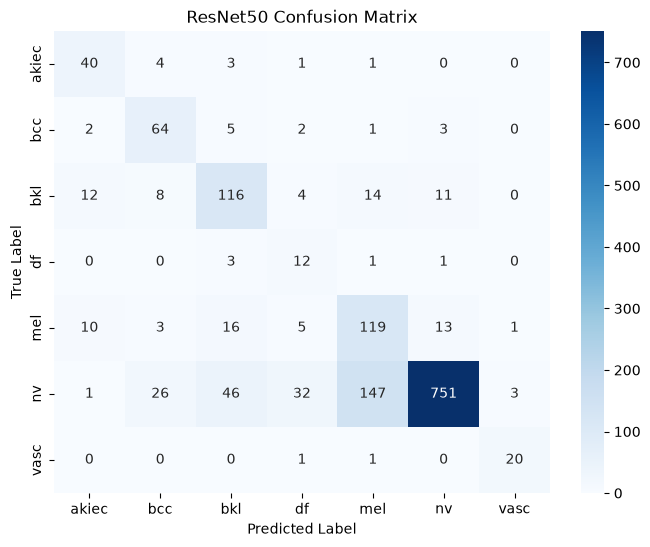

[SUCCESS] Confusion matrix generated.


In [22]:
# ==========================================
# STEP 20: CONFUSION MATRIX
# ==========================================

from sklearn.metrics import confusion_matrix
import seaborn as sns

print("=" * 60)
print("[INFO] Generating confusion matrix...")
print("=" * 60)

cm = confusion_matrix(y_true, y_pred)

class_names = [
    "akiec",
    "bcc",
    "bkl",
    "df",
    "mel",
    "nv",
    "vasc"
]

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("ResNet50 Confusion Matrix")

plt.show()

print("=" * 60)
print("[SUCCESS] Confusion matrix generated.")
print("=" * 60)

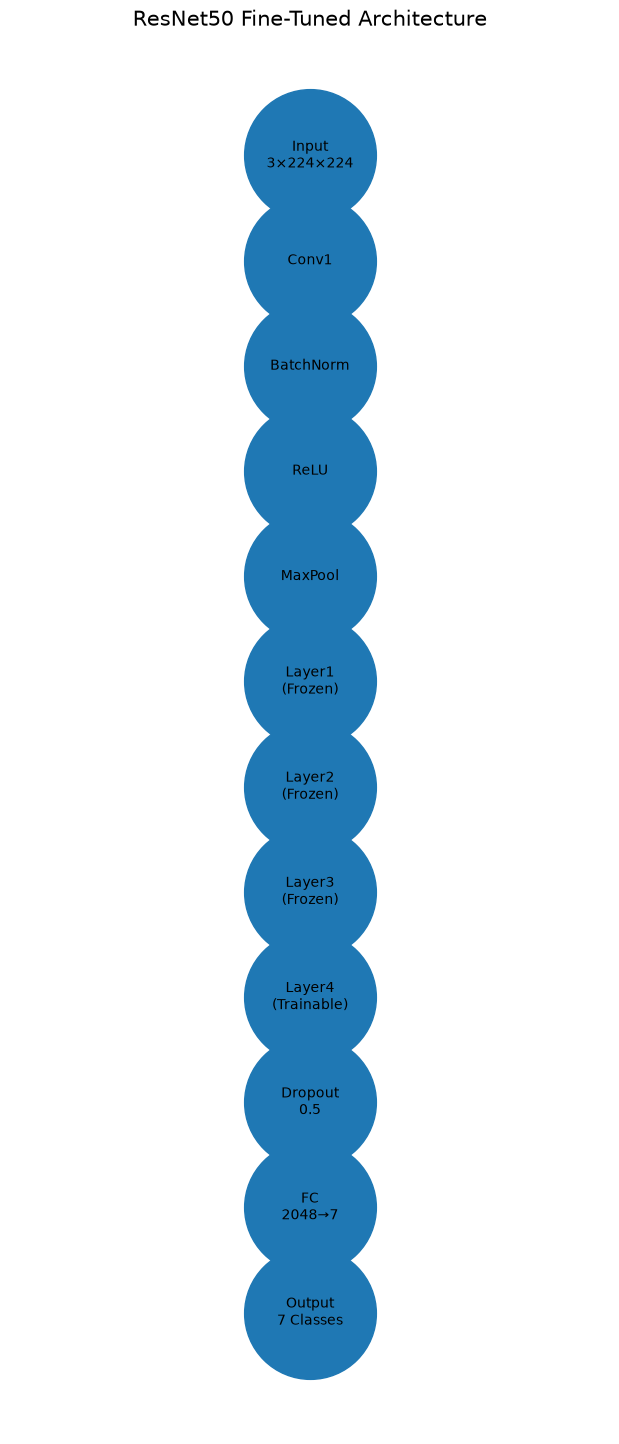

In [24]:
import networkx as nx
import matplotlib.pyplot as plt

# Create graph
G = nx.DiGraph()

layers = [
    "Input\n3×224×224",
    "Conv1",
    "BatchNorm",
    "ReLU",
    "MaxPool",
    "Layer1\n(Frozen)",
    "Layer2\n(Frozen)",
    "Layer3\n(Frozen)",
    "Layer4\n(Trainable)",
    "Dropout\n0.5",
    "FC\n2048→7",
    "Output\n7 Classes"
]

# Add edges
for i in range(len(layers)-1):
    G.add_edge(layers[i], layers[i+1])

# Position nodes vertically
pos = {layer: (0, -i) for i, layer in enumerate(layers)}

plt.figure(figsize=(6, 14))

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=9000,
    font_size=10,
    arrows=True
)

plt.title("ResNet50 Fine-Tuned Architecture", fontsize=15)
plt.axis('off')

plt.show()

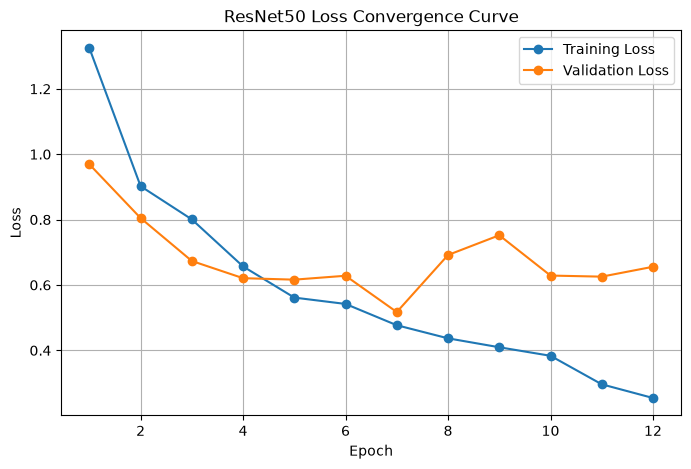

In [26]:
import matplotlib.pyplot as plt

# Epochs
epochs = range(1, 13)

# Loss values from your logs
train_losses_resnet = [
    1.3249, 0.9022, 0.8006, 0.6567,
    0.5614, 0.5420, 0.4769, 0.4368,
    0.4095, 0.3834, 0.2962, 0.2543
]

val_losses_resnet = [
    0.9692, 0.8047, 0.6734, 0.6208,
    0.6163, 0.6282, 0.5172, 0.6917,
    0.7521, 0.6288, 0.6255, 0.6557
]

plt.figure(figsize=(8,5))

plt.plot(
    epochs,
    train_losses_resnet,
    marker='o',
    label='Training Loss'
)

plt.plot(
    epochs,
    val_losses_resnet,
    marker='o',
    label='Validation Loss'
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet50 Loss Convergence Curve")
plt.legend()
plt.grid()

# Optional save
plt.savefig(
    "../reports/figures/resnet50_loss_curve.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()